In [1]:
# Filtering out the warnings

import warnings

warnings.filterwarnings('ignore')

In [2]:
# Importing the required libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# <font color = blue> IMDb Movie Assignment </font>

You have the data for the 100 top-rated movies from the past decade along with various pieces of information about the movie, its actors, and the voters who have rated these movies online. In this assignment, you will try to find some interesting insights into these movies and their voters, using Python.

##  Task 1: Reading the data

- ### Subtask 1.1: Read the Movies Data.

Read the movies data file provided and store it in a dataframe `movies`.

In [3]:
# Read the csv file using 'read_csv'. Please write your dataset location here.
data=pd.read_csv(r"D:\Rakesh\LogicMojo-AI-ML-June26-rakesh\Data\Movie+Assignment+Data.csv")


In [4]:
data.head()

,Title,title_year,budget,Gross,actor_1_name,actor_2_name,actor_3_name,actor_1_facebook_likes,actor_2_facebook_likes,actor_3_facebook_likes,...,Votes3044M,Votes3044F,Votes45A,Votes45AM,Votes45AF,Votes1000,VotesUS,VotesnUS,content_rating,Country
0,La La Land,2016,30000000,151101803,Ryan Gosling,Emma Stone,Amiée Conn,14000,19000.0,NaN,...,7.9,7.8,7.6,7.6,7.5,7.1,8.3,8.1,PG-13,USA
1,Zootopia,2016,150000000,341268248,Ginnifer Goodwin,Jason Bateman,Idris Elba,2800,28000.0,27000.0,...,7.8,8.1,7.8,7.8,8.1,7.6,8.0,8.0,PG,USA
2,Lion,2016,12000000,51738905,Dev Patel,Nicole Kidman,Rooney Mara,33000,96000.0,9800.0,...,7.9,8.2,8.0,7.9,8.4,7.1,8.1,8.0,PG-13,Australia
3,Arrival,2016,47000000,100546139,Amy Adams,Jeremy Renner,Forest Whitaker,35000,5300.0,NaN,...,7.8,7.8,7.6,7.6,7.7,7.3,8.0,7.9,PG-13,USA
4,Manchester by the Sea,2016,9000000,47695371,Casey Affleck,Michelle Williams,Kyle Chandler,518,71000.0,3300.0,...,7.7,7.7,7.6,7.6,7.6,7.1,7.9,7.8,R,USA


- ###  Subtask 1.2: Inspect the Dataframe

Inspect the dataframe for dimensions, null-values, and summary of different numeric columns.

In [5]:
# Check the number of rows and columns in the dataframe

data.shape
# data.size

(100, 62)

In [6]:
data.columns

Index(['Title', 'title_year', 'budget', 'Gross', 'actor_1_name',
       'actor_2_name', 'actor_3_name', 'actor_1_facebook_likes',
       'actor_2_facebook_likes', 'actor_3_facebook_likes', 'IMDb_rating',
       'genre_1', 'genre_2', 'genre_3', 'MetaCritic', 'Runtime', 'CVotes10',
       'CVotes09', 'CVotes08', 'CVotes07', 'CVotes06', 'CVotes05', 'CVotes04',
       'CVotes03', 'CVotes02', 'CVotes01', 'CVotesMale', 'CVotesFemale',
       'CVotesU18', 'CVotesU18M', 'CVotesU18F', 'CVotes1829', 'CVotes1829M',
       'CVotes1829F', 'CVotes3044', 'CVotes3044M', 'CVotes3044F', 'CVotes45A',
       'CVotes45AM', 'CVotes45AF', 'CVotes1000', 'CVotesUS', 'CVotesnUS',
       'VotesM', 'VotesF', 'VotesU18', 'VotesU18M', 'VotesU18F', 'Votes1829',
       'Votes1829M', 'Votes1829F', 'Votes3044', 'Votes3044M', 'Votes3044F',
       'Votes45A', 'Votes45AM', 'Votes45AF', 'Votes1000', 'VotesUS',
       'VotesnUS', 'content_rating', 'Country'],
      dtype='str')

In [7]:
# Check the column-wise info of the dataframe
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 62 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Title                   100 non-null    str    
 1   title_year              100 non-null    int64  
 2   budget                  100 non-null    int64  
 3   Gross                   100 non-null    int64  
 4   actor_1_name            100 non-null    str    
 5   actor_2_name            100 non-null    str    
 6   actor_3_name            100 non-null    str    
 7   actor_1_facebook_likes  100 non-null    int64  
 8   actor_2_facebook_likes  99 non-null     float64
 9   actor_3_facebook_likes  98 non-null     float64
 10  IMDb_rating             100 non-null    float64
 11  genre_1                 100 non-null    str    
 12  genre_2                 97 non-null     str    
 13  genre_3                 74 non-null     str    
 14  MetaCritic              95 non-null     float64
 15  R

In [8]:
data.columns[data.isnull().sum()>0].tolist()

['actor_2_facebook_likes',
 'actor_3_facebook_likes',
 'genre_2',
 'genre_3',
 'MetaCritic']

In [9]:
null_counts=data.isnull().sum()
null_counts[null_counts>0]

actor_2_facebook_likes     1
actor_3_facebook_likes     2
genre_2                    3
genre_3                   26
MetaCritic                 5
dtype: int64

In [10]:
# Check the summary for the numeric columns 

data.describe()

,title_year,budget,Gross,actor_1_facebook_likes,actor_2_facebook_likes,actor_3_facebook_likes,IMDb_rating,MetaCritic,Runtime,CVotes10,...,Votes1829F,Votes3044,Votes3044M,Votes3044F,Votes45A,Votes45AM,Votes45AF,Votes1000,VotesUS,VotesnUS
count,100.000000,1.000000e+02,1.000000e+02,100.000000,99.000000,98.000000,100.000000,95.000000,100.000000,100.000000,...,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,2012.820000,7.838400e+07,1.468679e+08,13407.270000,7377.303030,3002.153061,7.883000,78.252632,126.420000,73212.160000,...,7.982000,7.732000,7.723000,7.780000,7.65100,7.624000,7.770000,7.274000,7.958000,7.793000
std,1.919491,7.445295e+07,1.454004e+08,10649.037862,13471.568216,6940.301133,0.247433,9.122066,19.050799,82669.594746,...,0.321417,0.251814,0.260479,0.282128,0.21485,0.213258,0.301344,0.361987,0.232327,0.264099
min,2010.000000,3.000000e+06,2.238380e+05,39.000000,12.000000,0.000000,7.500000,62.000000,91.000000,6420.000000,...,7.300000,7.300000,7.200000,7.200000,7.10000,7.100000,7.000000,6.400000,7.500000,7.300000
25%,2011.000000,1.575000e+07,4.199752e+07,1000.000000,580.000000,319.750000,7.700000,72.000000,114.750000,30587.000000,...,7.700000,7.600000,7.500000,7.600000,7.50000,7.475000,7.500000,7.100000,7.800000,7.600000
50%,2013.000000,4.225000e+07,1.070266e+08,13000.000000,1000.000000,626.500000,7.800000,78.000000,124.000000,54900.500000,...,8.000000,7.700000,7.700000,7.800000,7.65000,7.600000,7.800000,7.300000,7.950000,7.750000
75%,2014.000000,1.500000e+08,2.107548e+08,20000.000000,11000.000000,1000.000000,8.100000,83.500000,136.250000,80639.000000,...,8.200000,7.900000,7.900000,8.000000,7.80000,7.800000,7.925000,7.500000,8.100000,7.925000
max,2016.000000,2.600000e+08,9.366622e+08,35000.000000,96000.000000,46000.000000,8.800000,100.000000,180.000000,584839.000000,...,8.800000,8.700000,8.700000,8.500000,8.10000,8.100000,8.500000,8.200000,8.700000,8.800000


## Task 2: Data Analysis

Now that we have loaded the dataset and inspected it, we see that most of the data is in place. As of now, no data cleaning is required, so let's start with some data manipulation, analysis, and visualisation to get various insights about the data. 

-  ###  Subtask 2.1: Reduce those Digits!

These numbers in the `budget` and `gross` are too big, compromising its readability. Let's convert the unit of the `budget` and `gross` columns from `$` to `million $` first.

In [75]:
# Divide the 'gross' and 'budget' columns by 1000000 to convert '$' to 'million $'
# data=pd.read_csv(r"D:\Rakesh\LogicMojo-AI-ML-June26-rakesh\Data\Movie+Assignment+Data.csv")
data['budget'] = data['budget'] / 1000000
data['Gross'] = data['Gross'] / 1000000
data.head()

,Title,title_year,budget,Gross,actor_1_name,actor_2_name,actor_3_name,actor_1_facebook_likes,actor_2_facebook_likes,actor_3_facebook_likes,...,Votes3044M,Votes3044F,Votes45A,Votes45AM,Votes45AF,Votes1000,VotesUS,VotesnUS,content_rating,Country
0,La La Land,2016,0.000030,0.000151,Ryan Gosling,Emma Stone,Amiée Conn,14000,19000.0,NaN,...,7.9,7.8,7.6,7.6,7.5,7.1,8.3,8.1,PG-13,USA
1,Zootopia,2016,0.000150,0.000341,Ginnifer Goodwin,Jason Bateman,Idris Elba,2800,28000.0,27000.0,...,7.8,8.1,7.8,7.8,8.1,7.6,8.0,8.0,PG,USA
2,Lion,2016,0.000012,0.000052,Dev Patel,Nicole Kidman,Rooney Mara,33000,96000.0,9800.0,...,7.9,8.2,8.0,7.9,8.4,7.1,8.1,8.0,PG-13,Australia
3,Arrival,2016,0.000047,0.000101,Amy Adams,Jeremy Renner,Forest Whitaker,35000,5300.0,NaN,...,7.8,7.8,7.6,7.6,7.7,7.3,8.0,7.9,PG-13,USA
4,Manchester by the Sea,2016,0.000009,0.000048,Casey Affleck,Michelle Williams,Kyle Chandler,518,71000.0,3300.0,...,7.7,7.7,7.6,7.6,7.6,7.1,7.9,7.8,R,USA


-  ###  Subtask 2.2: Let's Talk Profit!

    1. Create a new column called `profit` which contains the difference of the two columns: `gross` and `budget`.
    2. Sort the dataframe using the `profit` column as reference.
    3. Extract the top ten profiting movies in descending order and store them in a new dataframe - `top10`.
    4. Plot a scatter or a joint plot between the columns `budget` and `profit` and write a few words on what you observed.
    5. Extract the movies with a negative profit and store them in a new dataframe - `neg_profit`

In [12]:
# Create the new column named 'profit' by subtracting the 'budget' column from the 'gross' column
data['profit']=data['Gross']-data['budget']
data.profit
data.head()

,Title,title_year,budget,Gross,actor_1_name,actor_2_name,actor_3_name,actor_1_facebook_likes,actor_2_facebook_likes,actor_3_facebook_likes,...,Votes3044F,Votes45A,Votes45AM,Votes45AF,Votes1000,VotesUS,VotesnUS,content_rating,Country,profit
0,La La Land,2016,30.0,151.101803,Ryan Gosling,Emma Stone,Amiée Conn,14000,19000.0,NaN,...,7.8,7.6,7.6,7.5,7.1,8.3,8.1,PG-13,USA,121.101803
1,Zootopia,2016,150.0,341.268248,Ginnifer Goodwin,Jason Bateman,Idris Elba,2800,28000.0,27000.0,...,8.1,7.8,7.8,8.1,7.6,8.0,8.0,PG,USA,191.268248
2,Lion,2016,12.0,51.738905,Dev Patel,Nicole Kidman,Rooney Mara,33000,96000.0,9800.0,...,8.2,8.0,7.9,8.4,7.1,8.1,8.0,PG-13,Australia,39.738905
3,Arrival,2016,47.0,100.546139,Amy Adams,Jeremy Renner,Forest Whitaker,35000,5300.0,NaN,...,7.8,7.6,7.6,7.7,7.3,8.0,7.9,PG-13,USA,53.546139
4,Manchester by the Sea,2016,9.0,47.695371,Casey Affleck,Michelle Williams,Kyle Chandler,518,71000.0,3300.0,...,7.7,7.6,7.6,7.6,7.1,7.9,7.8,R,USA,38.695371


In [13]:
# Sort the dataframe with the 'profit' column as reference using the 'sort_values' function. Make sure to set the argument
#'ascending' to 'False'
data.sort_values(by='profit',ascending=False,inplace=True)
data.head()


,Title,title_year,budget,Gross,actor_1_name,actor_2_name,actor_3_name,actor_1_facebook_likes,actor_2_facebook_likes,actor_3_facebook_likes,...,Votes3044F,Votes45A,Votes45AM,Votes45AF,Votes1000,VotesUS,VotesnUS,content_rating,Country,profit
97,Star Wars: Episode VII - The Force Awakens,2015,245.0,936.662225,Doug Walker,Rob Walker,0,131,12.0,0.0,...,8.2,7.9,7.8,8.2,7.7,8.2,7.9,PG-13,USA,691.662225
11,The Avengers,2012,220.0,623.279547,Chris Hemsworth,Robert Downey Jr.,Scarlett Johansson,26000,21000.0,19000.0,...,8.1,7.9,7.9,8.1,7.4,8.3,7.9,PG-13,USA,403.279547
47,Deadpool,2016,58.0,363.024263,Ryan Reynolds,Ed Skrein,Stefan Kapicic,16000,805.0,361.0,...,7.9,7.8,7.8,7.9,7.3,8.1,7.9,R,USA,305.024263
32,The Hunger Games: Catching Fire,2013,130.0,424.645577,Jennifer Lawrence,Josh Hutcherson,Sandra Ellis Lafferty,34000,14000.0,523.0,...,7.9,7.3,7.2,7.9,6.7,7.7,7.4,PG-13,USA,294.645577
12,Toy Story 3,2010,200.0,414.984497,Tom Hanks,John Ratzenberger,Don Rickles,15000,1000.0,721.0,...,8.3,8.1,8.1,8.1,8.1,8.5,8.3,G,USA,214.984497


In [14]:
# Get the top 10 profitable movies by using position based indexing. Specify the rows till 10 (0-9)
# data.head(10)

data.iloc[0:10]



,Title,title_year,budget,Gross,actor_1_name,actor_2_name,actor_3_name,actor_1_facebook_likes,actor_2_facebook_likes,actor_3_facebook_likes,...,Votes3044F,Votes45A,Votes45AM,Votes45AF,Votes1000,VotesUS,VotesnUS,content_rating,Country,profit
97,Star Wars: Episode VII - The Force Awakens,2015,245.0,936.662225,Doug Walker,Rob Walker,0,131,12.0,0.0,...,8.2,7.9,7.8,8.2,7.7,8.2,7.9,PG-13,USA,691.662225
11,The Avengers,2012,220.0,623.279547,Chris Hemsworth,Robert Downey Jr.,Scarlett Johansson,26000,21000.0,19000.0,...,8.1,7.9,7.9,8.1,7.4,8.3,7.9,PG-13,USA,403.279547
47,Deadpool,2016,58.0,363.024263,Ryan Reynolds,Ed Skrein,Stefan Kapicic,16000,805.0,361.0,...,7.9,7.8,7.8,7.9,7.3,8.1,7.9,R,USA,305.024263
32,The Hunger Games: Catching Fire,2013,130.0,424.645577,Jennifer Lawrence,Josh Hutcherson,Sandra Ellis Lafferty,34000,14000.0,523.0,...,7.9,7.3,7.2,7.9,6.7,7.7,7.4,PG-13,USA,294.645577
12,Toy Story 3,2010,200.0,414.984497,Tom Hanks,John Ratzenberger,Don Rickles,15000,1000.0,721.0,...,8.3,8.1,8.1,8.1,8.1,8.5,8.3,G,USA,214.984497
8,The Dark Knight Rises,2012,250.0,448.130642,Tom Hardy,Christian Bale,Joseph Gordon-Levitt,27000,23000.0,23000.0,...,8.2,7.9,7.9,7.9,7.8,8.4,8.4,PG-13,USA,198.130642
45,The Lego Movie,2014,60.0,257.756197,Morgan Freeman,Will Ferrell,Alison Brie,11000,8000.0,2000.0,...,7.5,7.4,7.4,7.4,7.2,8.0,7.6,PG,Australia,197.756197
1,Zootopia,2016,150.0,341.268248,Ginnifer Goodwin,Jason Bateman,Idris Elba,2800,28000.0,27000.0,...,8.1,7.8,7.8,8.1,7.6,8.0,8.0,PG,USA,191.268248
41,Despicable Me,2010,69.0,251.501645,Steve Carell,Miranda Cosgrove,Jack McBrayer,7000,2000.0,975.0,...,7.9,7.6,7.5,7.9,7.0,7.6,7.6,PG,USA,182.501645
18,Inside Out,2015,175.0,356.454367,Amy Poehler,Mindy Kaling,Phyllis Smith,1000,767.0,384.0,...,8.1,7.9,7.9,7.9,7.6,8.2,8.1,PG,USA,181.454367


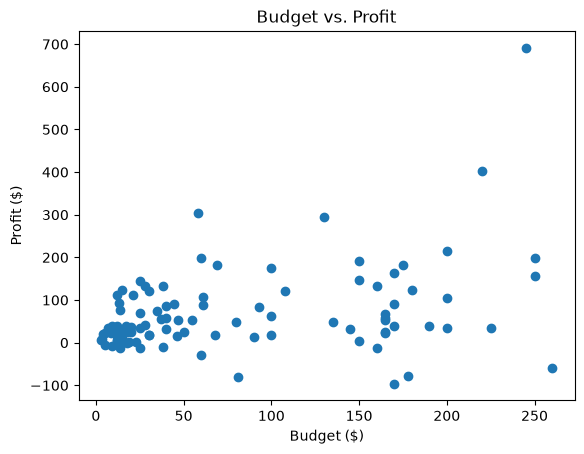

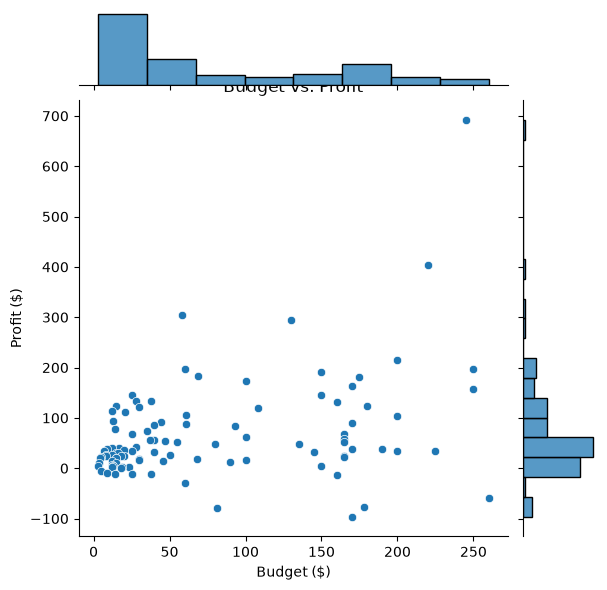

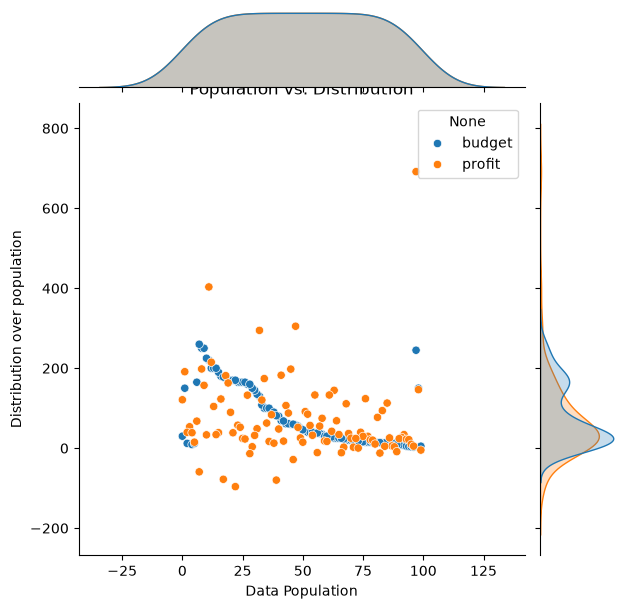

In [15]:
#Plot profit vs budget

plt.scatter(x=data['budget'],y=data['profit'])
plt.xlabel('Budget ($)')
plt.ylabel('Profit ($)')
plt.title('Budget vs. Profit')
plt.show()

sns.jointplot(data=data,x='budget',y='profit')
plt.xlabel('Budget ($)')
plt.ylabel('Profit ($)')
plt.title('Budget vs. Profit')
plt.show()

sns.jointplot(data=data[['budget','profit']])
plt.xlabel('Data Population')
plt.ylabel('Distribution over population')
plt.title('Population vs. Distribution')
plt.show()

The dataset contains the 100 best performing movies from the year 2010 to 2016. However scatter plot tells a different story. You can notice that there are some movies with negative profit. Although good movies do incur losses, but there appear to be quite a few movie with losses. What can be the reason behind this? Lets have a closer look at this by finding the movies with negative profit.

In [16]:
#Find the movies with negative profit

loss_movies=data[data.profit<0]
loss_movies.profit.value_counts()

profit
-4.776162     1
-8.674623     1
-11.096291    1
-11.348338    1
-12.247786    1
-13.594629    1
-28.505730    1
-59.192738    1
-77.810499    1
-79.860848    1
-96.179906    1
Name: count, dtype: int64

In [17]:
loss_movies.info()

<class 'pandas.DataFrame'>
Index: 11 entries, 99 to 22
Data columns (total 63 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Title                   11 non-null     str    
 1   title_year              11 non-null     int64  
 2   budget                  11 non-null     float64
 3   Gross                   11 non-null     float64
 4   actor_1_name            11 non-null     str    
 5   actor_2_name            11 non-null     str    
 6   actor_3_name            11 non-null     str    
 7   actor_1_facebook_likes  11 non-null     int64  
 8   actor_2_facebook_likes  11 non-null     float64
 9   actor_3_facebook_likes  11 non-null     float64
 10  IMDb_rating             11 non-null     float64
 11  genre_1                 11 non-null     str    
 12  genre_2                 11 non-null     str    
 13  genre_3                 9 non-null      str    
 14  MetaCritic              10 non-null     float64
 15  Runtim

**`Checkpoint 1:`** Can you spot the movie `Tangled` in the dataset? You may be aware of the movie 'Tangled'. Although its one of the highest grossing movies of all time, it has negative profit as per this result. If you cross check the gross values of this movie (link: https://www.imdb.com/title/tt0398286/), you can see that the gross in the dataset accounts only for the domestic gross and not the worldwide gross. This is true for may other movies also in the list.

- ### Subtask 2.3: The General Audience and the Critics

You might have noticed the column `MetaCritic` in this dataset. This is a very popular website where an average score is determined through the scores given by the top-rated critics. Second, you also have another column `IMDb_rating` which tells you the IMDb rating of a movie. This rating is determined by taking the average of hundred-thousands of ratings from the general audience. 

As a part of this subtask, you are required to find out the highest rated movies which have been liked by critics and audiences alike.
1. Firstly you will notice that the `MetaCritic` score is on a scale of `100` whereas the `IMDb_rating` is on a scale of 10. First convert the `MetaCritic` column to a scale of 10.
2. Now, to find out the movies which have been liked by both critics and audiences alike and also have a high rating overall, you need to -
    - Create a new column `Avg_rating` which will have the average of the `MetaCritic` and `Rating` columns
    - Retain only the movies in which the absolute difference(using abs() function) between the `IMDb_rating` and `Metacritic` columns is less than 0.5. Refer to this link to know how abs() funtion works - https://www.geeksforgeeks.org/abs-in-python/ .
    - Sort these values in a descending order of `Avg_rating` and retain only the movies with a rating equal to higher than `8` and store these movies in a new dataframe `UniversalAcclaim`.
    

In [76]:
# Change the scale of MetaCritic

data['MetaCritic']=data['MetaCritic']/10

data['MetaCritic'].unique()
# data.head()

array([ 9.3,  7.8,  6.9,  8.1,  9.6,  8.8,  7.2,  7.1,  7.5,  6.6,  9.2,
        7.4,  nan,  9.4,  7.6,  7. ,  7.9,  8.3,  6.5,  9. ,  8. ,  6.8,
        6.3,  6.4,  8.7,  8.6,  9.5,  8.2,  6.2,  8.4,  8.9,  7.3,  6.7,
        7.7, 10. ])

In [77]:
# Find the average ratings

data["Avg_rating"]=(data["MetaCritic"] +data["IMDb_rating"])/2
data["Avg_rating"]
# data['Avg_rating'].unique()

0     8.75
1     7.95
2     7.50
3     8.05
4     8.75
      ... 
95    8.65
96    8.65
97    8.10
98    7.10
99    7.05
Name: Avg_rating, Length: 100, dtype: float64

In [78]:
#Sort in descending order of average rating
data.sort_values(by="Avg_rating",ascending=False).copy()


,Title,title_year,budget,Gross,actor_1_name,actor_2_name,actor_3_name,actor_1_facebook_likes,actor_2_facebook_likes,actor_3_facebook_likes,...,Votes3044F,Votes45A,Votes45AM,Votes45AF,Votes1000,VotesUS,VotesnUS,content_rating,Country,Avg_rating
94,Boyhood,2014,0.000004,0.000025,Ellar Coltrane,Lorelei Linklater,Libby Villari,230,193.0,127.0,...,7.6,7.7,7.7,7.7,7.2,8.0,7.9,R,USA,8.95
69,12 Years a Slave,2013,0.000020,0.000057,QuvenzhanÃ© Wallis,Scoot McNairy,Taran Killam,2000,660.0,500.0,...,8.0,7.8,7.8,8.1,7.7,8.3,8.0,R,USA,8.85
18,Inside Out,2015,0.000175,0.000356,Amy Poehler,Mindy Kaling,Phyllis Smith,1000,767.0,384.0,...,8.1,7.9,7.9,7.9,7.6,8.2,8.1,PG,USA,8.80
12,Toy Story 3,2010,0.000200,0.000415,Tom Hanks,John Ratzenberger,Don Rickles,15000,1000.0,721.0,...,8.3,8.1,8.1,8.1,8.1,8.5,8.3,G,USA,8.75
0,La La Land,2016,0.000030,0.000151,Ryan Gosling,Emma Stone,Amiée Conn,14000,19000.0,NaN,...,7.8,7.6,7.6,7.5,7.1,8.3,8.1,PG-13,USA,8.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16,The Hobbit: An Unexpected Journey,2012,0.000180,0.000303,Aidan Turner,Adam Brown,James Nesbitt,5000,972.0,773.0,...,7.9,7.7,7.6,8.0,7.5,7.8,7.8,PG-13,USA,NaN
52,Lone Survivor,2013,0.000040,0.000125,Jerry Ferrara,Scott Elrod,Dan Bilzerian,480,449.0,127.0,...,7.6,7.5,7.4,7.8,6.8,7.8,7.3,R,USA,NaN
71,The Book Thief,2013,0.000019,0.000021,Emily Watson,Sophie NÃ©lisse,Roger Allam,876,526.0,326.0,...,7.7,7.6,7.5,8.0,6.6,7.6,7.5,PG-13,USA,NaN
82,Flipped,2010,0.000014,0.000002,Madeline Carroll,Rebecca De Mornay,Aidan Quinn,1000,872.0,767.0,...,7.7,7.4,7.3,7.6,6.4,7.5,7.7,PG,USA,NaN


In [103]:
# Find the movies with metacritic-rating < 0.5 and also with the average rating of >8
metaRating=data[(abs(data['MetaCritic']-data['IMDb_rating'])<0.5) & (data.Avg_rating>=8)]
metaRating.head()


,Title,title_year,budget,Gross,actor_1_name,actor_2_name,actor_3_name,actor_1_facebook_likes,actor_2_facebook_likes,actor_3_facebook_likes,...,Votes3044F,Votes45A,Votes45AM,Votes45AF,Votes1000,VotesUS,VotesnUS,content_rating,Country,Avg_rating
3,Arrival,2016,0.000047,0.000101,Amy Adams,Jeremy Renner,Forest Whitaker,35000,5300.0,NaN,...,7.8,7.6,7.6,7.7,7.3,8.0,7.9,PG-13,USA,8.05
33,The Martian,2015,0.000108,0.000228,Matt Damon,Donald Glover,Benedict Wong,13000,801.0,372.0,...,7.9,8.0,7.9,8.2,7.8,8.1,7.9,PG-13,USA,8.00
35,Django Unchained,2012,0.000100,0.000163,Leonardo DiCaprio,Christoph Waltz,Ato Essandoh,29000,11000.0,265.0,...,8.3,8.0,8.0,8.1,7.8,8.4,8.4,R,USA,8.25
43,Gone Girl,2014,0.000061,0.000168,Patrick Fugit,Sela Ward,Emily Ratajkowski,835,812.0,625.0,...,7.9,7.7,7.7,7.7,7.6,8.1,8.1,R,USA,8.00
93,Dallas Buyers Club,2013,0.000005,0.000027,Matthew McConaughey,Jennifer Garner,Denis O'Hare,11000,3000.0,896.0,...,8.0,7.8,7.8,8.0,7.2,8.0,7.9,R,USA,8.20


**`Checkpoint 2:`** Can you spot a `Star Wars` movie in your final dataset?

- ### Subtask 2.4: Find the Most Popular Trios - I

You're a producer looking to make a blockbuster movie. There will primarily be three lead roles in your movie and you wish to cast the most popular actors for it. Now, since you don't want to take a risk, you will cast a trio which has already acted in together in a movie before. The metric that you've chosen to check the popularity is the Facebook likes of each of these actors.

The dataframe has three columns to help you out for the same, viz. `actor_1_facebook_likes`, `actor_2_facebook_likes`, and `actor_3_facebook_likes`. Your objective is to find the trios which has the most number of Facebook likes combined. That is, the sum of `actor_1_facebook_likes`, `actor_2_facebook_likes` and `actor_3_facebook_likes` should be maximum.
Find out the top 5 popular trios, and output their names in a list.


In [104]:
data

,Title,title_year,budget,Gross,actor_1_name,actor_2_name,actor_3_name,actor_1_facebook_likes,actor_2_facebook_likes,actor_3_facebook_likes,...,Votes3044F,Votes45A,Votes45AM,Votes45AF,Votes1000,VotesUS,VotesnUS,content_rating,Country,Avg_rating
0,La La Land,2016,0.000030,1.511018e-04,Ryan Gosling,Emma Stone,Amiée Conn,14000,19000.0,NaN,...,7.8,7.6,7.6,7.5,7.1,8.3,8.1,PG-13,USA,8.75
1,Zootopia,2016,0.000150,3.412682e-04,Ginnifer Goodwin,Jason Bateman,Idris Elba,2800,28000.0,27000.0,...,8.1,7.8,7.8,8.1,7.6,8.0,8.0,PG,USA,7.95
2,Lion,2016,0.000012,5.173891e-05,Dev Patel,Nicole Kidman,Rooney Mara,33000,96000.0,9800.0,...,8.2,8.0,7.9,8.4,7.1,8.1,8.0,PG-13,Australia,7.50
3,Arrival,2016,0.000047,1.005461e-04,Amy Adams,Jeremy Renner,Forest Whitaker,35000,5300.0,NaN,...,7.8,7.6,7.6,7.7,7.3,8.0,7.9,PG-13,USA,8.05
4,Manchester by the Sea,2016,0.000009,4.769537e-05,Casey Affleck,Michelle Williams,Kyle Chandler,518,71000.0,3300.0,...,7.7,7.6,7.6,7.6,7.1,7.9,7.8,R,USA,8.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Whiplash,2014,0.000003,1.309200e-05,J.K. Simmons,Melissa Benoist,Chris Mulkey,24000,970.0,535.0,...,8.2,8.1,8.1,8.2,8.0,8.6,8.4,R,USA,8.65
96,Before Midnight,2013,0.000003,8.114507e-06,Seamus Davey-Fitzpatrick,Ariane Labed,Athina Rachel Tsangari,140,63.0,48.0,...,7.6,7.3,7.4,7.2,7.0,8.0,7.9,R,USA,8.65
97,Star Wars: Episode VII - The Force Awakens,2015,0.000245,9.366622e-04,Doug Walker,Rob Walker,0,131,12.0,0.0,...,8.2,7.9,7.8,8.2,7.7,8.2,7.9,PG-13,USA,8.10
98,Harry Potter and the Deathly Hallows: Part I,2010,0.000150,2.963477e-04,Rupert Grint,Toby Jones,Alfred Enoch,10000,2000.0,1000.0,...,8.1,7.4,7.3,8.0,6.7,7.9,7.5,PG-13,UK,7.10


In [111]:
# Write your code here

actor_trios=pd.pivot_table(
                        data=data,
                        index=["actor_1_name","actor_2_name","actor_3_name"],
                        values=["actor_1_facebook_likes","actor_2_facebook_likes","actor_1_facebook_likes"],
                        aggfunc=np.sum
                        )
actor_trios["total_likes"] = actor_trios.sum(axis=1)
actor_trios = actor_trios.sort_values(by="total_likes", ascending=False)
actor_trios.head()

actor_1_facebook_likes  \
actor_1_name      actor_2_name    actor_3_name                                    
Dev Patel         Nicole Kidman   Rooney Mara                             33000   
Jennifer Lawrence Robert De Niro  Bradley Cooper                          34000   
                  Peter Dinklage  Hugh Jackman                            34000   
Ryan Gosling      Christian Bale  Charlie Talbert                         33000   
Jennifer Lawrence Josh Hutcherson Sandra Ellis Lafferty                   34000   

                                                         actor_1_facebook_likes  \
actor_1_name      actor_2_name    actor_3_name                                    
Dev Patel         Nicole Kidman   Rooney Mara                             33000   
Jennifer Lawrence Robert De Niro  Bradley Cooper                          34000   
                  Peter Dinklage  Hugh Jackman                            34000   
Ryan Gosling      Christian Bale  Charlie Talbert                         33000   
Jennifer Lawrence Josh Hutcherson Sandra Ellis Lafferty                   34000   

                                                         actor_1_facebook_likes  \
actor_1_name      actor_2_name    actor_3_name                                    
Dev Patel         Nicole Kidman   Rooney Mara                             33000   
Jennifer Lawrence Robert De Niro  Bradley Cooper                          34000   
                  Peter Dinklage  Hugh Jackman                            34000   
Ryan Gosling      Christian Bale  Charlie Talbert                         33000   
Jennifer Lawrence Josh Hutcherson Sandra Ellis Lafferty                   34000   

                                                         actor_1_facebook_likes  \
actor_1_name      actor_2_name    actor_3_name                                    
Dev Patel         Nicole Kidman   Rooney Mara                             33000   
Jennifer Lawrence Robert De Niro  Bradley Cooper                          34000   
                  Peter Dinklage  Hugh Jackman                            34000   
Ryan Gosling      Christian Bale  Charlie Talbert                         33000   
Jennifer Lawrence Josh Hutcherson Sandra Ellis Lafferty                   34000   

                                                         actor_2_facebook_likes  \
actor_1_name      actor_2_name    actor_3_name                                    
Dev Patel         Nicole Kidman   Rooney Mara                           96000.0   
Jennifer Lawrence Robert De Niro  Bradley Cooper                        22000.0   
                  Peter Dinklage  Hugh Jackman                          22000.0   
Ryan Gosling      Christian Bale  Charlie Talbert                       23000.0   
Jennifer Lawrence Josh Hutcherson Sandra Ellis Lafferty                 14000.0   

                                                         total_likes  
actor_1_name      actor_2_name    actor_3_name                        
Dev Patel         Nicole Kidman   Rooney Mara               228000.0  
Jennifer Lawrence Robert De Niro  Bradley Cooper            158000.0  
                  Peter Dinklage  Hugh Jackman              158000.0  
Ryan Gosling      Christian Bale  Charlie Talbert           155000.0  
Jennifer Lawrence Josh Hutcherson Sandra Ellis Lafferty     150000.0

In [114]:
popular_trios=actor_trios.sort_values(by="total_likes", ascending=False).index.to_list()
popular_trios

[('Dev Patel', 'Nicole Kidman', 'Rooney Mara'),
 ('Jennifer Lawrence', 'Robert De Niro', 'Bradley Cooper'),
 ('Jennifer Lawrence', 'Peter Dinklage', 'Hugh Jackman'),
 ('Ryan Gosling', 'Christian Bale', 'Charlie Talbert'),
 ('Jennifer Lawrence', 'Josh Hutcherson', 'Sandra Ellis Lafferty'),
 ('Jennifer Lawrence', 'Michael Fassbender', 'Oliver Platt'),
 ('Amy Adams', 'Jeremy Renner', 'Forest Whitaker'),
 ('Leonardo DiCaprio', 'Tom Hardy', 'Lukas Haas'),
 ('Leonardo DiCaprio', 'Tom Hardy', 'Joseph Gordon-Levitt'),
 ('Ryan Gosling', 'Albert Brooks', 'Russ Tamblyn'),
 ('Tom Hardy', 'Christian Bale', 'Joseph Gordon-Levitt'),
 ('Leonardo DiCaprio', 'Christoph Waltz', 'Ato Essandoh'),
 ('Leonardo DiCaprio', 'Matthew McConaughey', 'Jon Favreau'),
 ('Chris Hemsworth', 'Robert Downey Jr.', 'Scarlett Johansson'),
 ('Tom Hardy', 'Charlize Theron', 'ZoÃ« Kravitz'),
 ('Leonardo DiCaprio', 'Joseph Sikora', 'Nellie Sciutto'),
 ('Chris Hemsworth', 'Olivia Wilde', 'Alexandra Maria Lara'),
 ('Tom Hardy', '

- ### Subtask 2.5: Find the Most Popular Trios - II

In the previous subtask you found the popular trio based on the total number of facebook likes. Let's add a small condition to it and make sure that all three actors are popular. The condition is **none of the three actors' Facebook likes should be less than half of the other two**. For example, the following is a valid combo:
- actor_1_facebook_likes: 70000
- actor_2_facebook_likes: 40000
- actor_3_facebook_likes: 50000

But the below one is not:
- actor_1_facebook_likes: 70000
- actor_2_facebook_likes: 40000
- actor_3_facebook_likes: 30000

since in this case, `actor_3_facebook_likes` is 30000, which is less than half of `actor_1_facebook_likes`.

Having this condition ensures that you aren't getting any unpopular actor in your trio (since the total likes calculated in the previous question doesn't tell anything about the individual popularities of each actor in the trio.).

You can do a manual inspection of the top 5 popular trios you have found in the previous subtask and check how many of those trios satisfy this condition. Also, which is the most popular trio after applying the condition above?

**Write your answers below.**

- **`No. of trios that satisfy the above condition:`**

- **`Most popular trio after applying the condition:`**

**`Optional:`** Even though you are finding this out by a natural inspection of the dataframe, can you also achieve this through some *if-else* statements to incorporate this. You can try this out on your own time after you are done with the assignment.

In [64]:
# Your answer here (optional)
actor_trios = pd.pivot_table(
    data=data,
    index=["actor_1_name", "actor_2_name", "actor_3_name"],
    values=["actor_1_facebook_likes", "actor_2_facebook_likes", "actor_3_facebook_likes"],
    aggfunc=np.sum
)
for lab,row in actor_trios.iterrows():
    if (row["actor_1_facebook_likes"] < row["actor_2_facebook_likes"] / 2) | (row["actor_1_facebook_likes"] < row["actor_3_facebook_likes"] / 2):
        actor_trios.loc[lab, "like_flage"] = "no"
    elif (row["actor_2_facebook_likes"] < row["actor_1_facebook_likes"] / 2) | (row["actor_2_facebook_likes"] < row["actor_3_facebook_likes"] / 2):
        actor_trios.loc[lab, "like_flage"] = "no"
    elif (row["actor_3_facebook_likes"] < row["actor_1_facebook_likes"] / 2) | (row["actor_3_facebook_likes"] < row["actor_2_facebook_likes"] / 2):
        actor_trios.loc[lab, "like_flage"] = "no"
    else:
        actor_trios.loc[lab, "like_flage"] = "yes"

actor_trios[actor_trios["like_flage"]=="yes"].head()

,,,actor_1_facebook_likes,actor_2_facebook_likes,actor_3_facebook_likes,like_flage
actor_1_name,actor_2_name,actor_3_name,,,,
Aldis Hodge,Neil Brown Jr.,R. Marcos Taylor,559,427.0,303.0,yes
BÃ©rÃ©nice Bejo,Ed Lauter,Beth Grant,996,897.0,628.0,yes
Chris Hemsworth,Robert Downey Jr.,Scarlett Johansson,26000,21000.0,19000.0,yes
Clea DuVall,Scoot McNairy,Tate Donovan,1000,660.0,650.0,yes
Damon Wayans Jr.,Daniel Henney,Abraham Benrubi,756,719.0,562.0,yes


In [65]:
actor_trios["total_likes"]=actor_trios["actor_1_facebook_likes"]+actor_trios["actor_2_facebook_likes"]+actor_trios["actor_3_facebook_likes"]
actor_trios

actor_1_facebook_likes  \
actor_1_name  actor_2_name    actor_3_name                                   
Aidan Turner  Adam Brown      James Nesbitt                          10000   
Albert Finney Helen McCrory   Rory Kinnear                             883   
Aldis Hodge   Neil Brown Jr.  R. Marcos Taylor                         559   
Amy Adams     Jeremy Renner   Forest Whitaker                        35000   
Amy Poehler   Mindy Kaling    Phyllis Smith                           1000   
...                                                                    ...   
Tom Hanks     Mark Rylance    Amy Ryan                               15000   
Tom Hardy     Charlize Theron ZoÃ« Kravitz                           27000   
              Christian Bale  Joseph Gordon-Levitt                   27000   
              Frank Grillo    Kevin Dunn                             27000   
Tom Hughes    Tom Hollander   Lindsay Duncan                           565   

                                                    actor_2_facebook_likes  \
actor_1_name  actor_2_name    actor_3_name                                   
Aidan Turner  Adam Brown      James Nesbitt                         1944.0   
Albert Finney Helen McCrory   Rory Kinnear                           563.0   
Aldis Hodge   Neil Brown Jr.  R. Marcos Taylor                       427.0   
Amy Adams     Jeremy Renner   Forest Whitaker                       5300.0   
Amy Poehler   Mindy Kaling    Phyllis Smith                          767.0   
...                                                                    ...   
Tom Hanks     Mark Rylance    Amy Ryan                               535.0   
Tom Hardy     Charlize Theron ZoÃ« Kravitz                          9000.0   
              Christian Bale  Joseph Gordon-Levitt                 23000.0   
              Frank Grillo    Kevin Dunn                             798.0   
Tom Hughes    Tom Hollander   Lindsay Duncan                         555.0   

                                                    actor_3_facebook_likes  \
actor_1_name  actor_2_name    actor_3_name                                   
Aidan Turner  Adam Brown      James Nesbitt                         1546.0   
Albert Finney Helen McCrory   Rory Kinnear                           393.0   
Aldis Hodge   Neil Brown Jr.  R. Marcos Taylor                       303.0   
Amy Adams     Jeremy Renner   Forest Whitaker                          0.0   
Amy Poehler   Mindy Kaling    Phyllis Smith                          384.0   
...                                                                    ...   
Tom Hanks     Mark Rylance    Amy Ryan                               423.0   
Tom Hardy     Charlize Theron ZoÃ« Kravitz                           943.0   
              Christian Bale  Joseph Gordon-Levitt                 23000.0   
              Frank Grillo    Kevin Dunn                             581.0   
Tom Hughes    Tom Hollander   Lindsay Duncan                         171.0   

                                                   like_flage  total_likes  
actor_1_name  actor_2_name    actor_3_name                                  
Aidan Turner  Adam Brown      James Nesbitt                no      13490.0  
Albert Finney Helen McCrory   Rory Kinnear                 no       1839.0  
Aldis Hodge   Neil Brown Jr.  R. Marcos Taylor            yes       1289.0  
Amy Adams     Jeremy Renner   Forest Whitaker              no      40300.0  
Amy Poehler   Mindy Kaling    Phyllis Smith                no       2151.0  
...                                                       ...          ...  
Tom Hanks     Mark Rylance    Amy Ryan                     no      15958.0  
Tom Hardy     Charlize Theron ZoÃ« Kravitz                 no      36943.0  
              Christian Bale  Joseph Gordon-Levitt        yes      73000.0  
              Frank Grillo    Kevin Dunn                   no      28379.0  
Tom Hughes    Tom Hollander   Lindsay Duncan               no       1291.0  

[99 r

In [66]:
popular_actor_trios=actor_trios.loc[actor_trios["like_flage"]=="yes",:].sort_values(by="total_likes",ascending=False)
popular_actor_trios

popular_actor_trios.index.tolist()


[('Leonardo DiCaprio', 'Tom Hardy', 'Joseph Gordon-Levitt'),
 ('Jennifer Lawrence', 'Peter Dinklage', 'Hugh Jackman'),
 ('Tom Hardy', 'Christian Bale', 'Joseph Gordon-Levitt'),
 ('Chris Hemsworth', 'Robert Downey Jr.', 'Scarlett Johansson'),
 ('Robert Downey Jr.', 'Scarlett Johansson', 'Chris Evans'),
 ('Philip Seymour Hoffman', 'Robin Wright', 'Brad Pitt'),
 ('Hugh Jackman', 'Eddie Redmayne', 'Anne Hathaway'),
 ('Jeff Bridges', 'James Franco', 'Mackenzie Foy'),
 ('Matthew McConaughey', 'Anne Hathaway', 'Mackenzie Foy'),
 ('Jack McBrayer', 'Sarah Silverman', 'Joe Lo Truglio'),
 ('Madeline Carroll', 'Rebecca De Mornay', 'Aidan Quinn'),
 ('BÃ©rÃ©nice Bejo', 'Ed Lauter', 'Beth Grant'),
 ('Devin Ratray', 'Bruce Dern', 'Will Forte'),
 ('Clea DuVall', 'Scoot McNairy', 'Tate Donovan'),
 ('Patrick Fugit', 'Sela Ward', 'Emily Ratajkowski'),
 ('Damon Wayans Jr.', 'Daniel Henney', 'Abraham Benrubi'),
 ('Elizabeth McGovern', 'Deborah Twiss', 'Michael Rispoli'),
 ('Aldis Hodge', 'Neil Brown Jr.', '

- ### Subtask 2.6: Runtime Analysis

There is a column named `Runtime` in the dataframe which primarily shows the length of the movie. It might be intersting to see how this variable this distributed. Plot a `histogram` or `distplot` of seaborn to find the `Runtime` range most of the movies fall into.

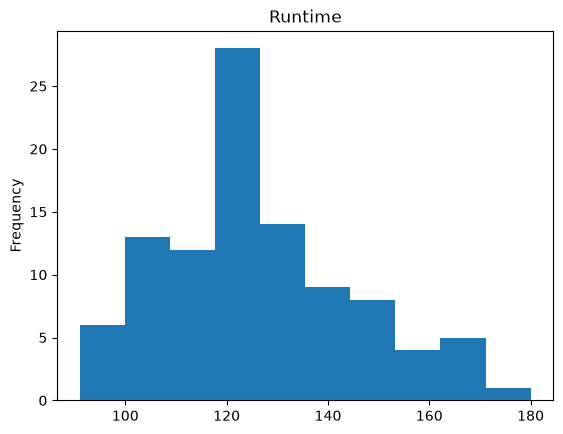

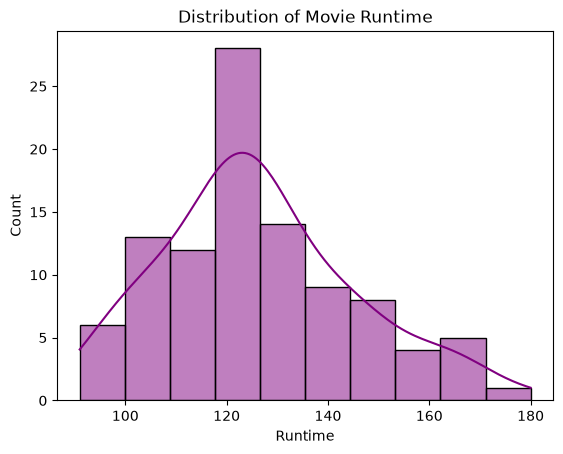

In [120]:
# Runtime histogram/density plot
data[["Runtime","Title"]]
data.Runtime.plot(kind="hist",title="Runtime")
plt.show()


# seaborn
import seaborn as sns
sns.histplot(data=data,x='Runtime',bins=10,kde=True,color='purple')
plt.title('Distribution of Movie Runtime')
plt.show()



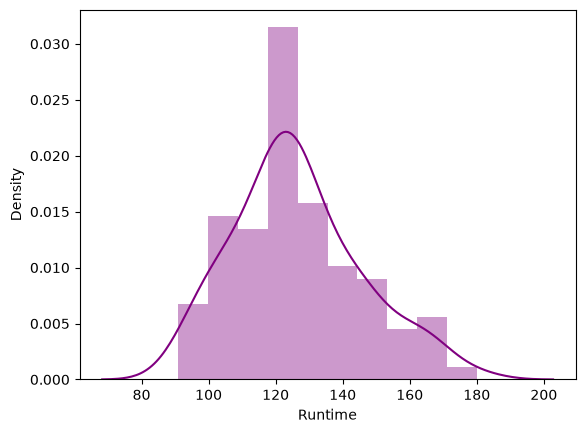

In [121]:
sns.distplot(data['Runtime'],bins=10,kde=True,color='purple')
plt.show()

In [125]:
min_runtime=int(data["Runtime"].min() // 10 * 10)
max_runtime=int(data["Runtime"].max() // 10 * 10) + 20
bins=range(min_runtime,max_runtime,10)

data["Class_Interval"]=pd.cut(data["Runtime"],bins=bins)
data.Class_Interval
summary_df=(
    data.groupby("Class_Interval",observed=False)["Title"]
    .agg(
        Frequency="count",
        Movies=lambda x:", ".join(x)
        if len(x)>0
        else "No movies"
    )
    .reset_index()
)
print(summary_df)

  Class_Interval  Frequency                                             Movies
0      (90, 100]         10  Inside Out, Gravity, The Lego Movie, The Grand...
1     (100, 110]         12  Zootopia, Hell or High Water, Toy Story 3, The...
2     (110, 120]         16  Lion, Arrival, Doctor Strange, Edge of Tomorro...
3     (120, 130]         26  La La Land, Tangled, Guardians of the Galaxy, ...
4     (130, 140]         14  Manchester by the Sea, X-Men: Days of Future P...
5     (140, 150]         11  Captain America: Civil War, The Avengers, Skyf...
6     (150, 160]          4  The Revenant, The Girl with the Dragon Tattoo,...
7     (160, 170]          6  The Dark Knight Rises, The Hobbit: The Desolat...
8     (170, 180]          1                            The Wolf of Wall Street
9     (180, 190]          0                                          No movies


**`Checkpoint 3:`** Most of the movies appear to be sharply 2 hour-long.

- ### Subtask 2.7: R-Rated Movies

Although R rated movies are restricted movies for the under 18 age group, still there are vote counts from that age group. Among all the R rated movies that have been voted by the under-18 age group, find the top 10 movies that have the highest number of votes i.e.`CVotesU18` from the `movies` dataframe. Store these in a dataframe named `PopularR`.

In [145]:
# Write your code here
PopularR=data[data["content_rating"]=="R"].sort_values(by="CVotesU18",ascending=False).head(10)
PopularR

,Title,title_year,budget,Gross,actor_1_name,actor_2_name,actor_3_name,actor_1_facebook_likes,actor_2_facebook_likes,actor_3_facebook_likes,...,Votes3044M,Votes3044F,Votes45A,Votes45AM,Votes45AF,Votes1000,VotesUS,VotesnUS,content_rating,Country
47,Deadpool,2016,58000000,363024263,Ryan Reynolds,Ed Skrein,Stefan Kapicic,16000,805.0,361.0,...,7.9,7.9,7.8,7.8,7.9,7.3,8.1,7.9,R,USA
36,The Wolf of Wall Street,2013,100000000,116866727,Leonardo DiCaprio,Matthew McConaughey,Jon Favreau,29000,11000.0,4000.0,...,8.1,7.7,7.6,7.6,7.5,7.8,8.1,8.1,R,USA
35,Django Unchained,2012,100000000,162804648,Leonardo DiCaprio,Christoph Waltz,Ato Essandoh,29000,11000.0,265.0,...,8.3,8.3,8.0,8.0,8.1,7.8,8.4,8.4,R,USA
29,Mad Max: Fury Road,2015,150000000,153629485,Tom Hardy,Charlize Theron,ZoÃ« Kravitz,27000,9000.0,943.0,...,8.0,7.8,7.5,7.5,7.2,8.0,8.2,8.0,R,Australia
95,Whiplash,2014,3300000,13092000,J.K. Simmons,Melissa Benoist,Chris Mulkey,24000,970.0,535.0,...,8.3,8.2,8.1,8.1,8.2,8.0,8.6,8.4,R,USA
31,The Revenant,2015,135000000,183635922,Leonardo DiCaprio,Tom Hardy,Lukas Haas,29000,27000.0,733.0,...,7.9,7.7,7.8,7.8,7.8,7.6,8.1,7.9,R,USA
40,Shutter Island,2010,80000000,127968405,Leonardo DiCaprio,Joseph Sikora,Nellie Sciutto,29000,223.0,163.0,...,7.9,8.0,7.5,7.4,7.6,7.6,7.8,8.1,R,USA
43,Gone Girl,2014,61000000,167735396,Patrick Fugit,Sela Ward,Emily Ratajkowski,835,812.0,625.0,...,8.0,7.9,7.7,7.7,7.7,7.6,8.1,8.1,R,USA
65,The Grand Budapest Hotel,2014,25000000,59073773,Bill Murray,Tom Wilkinson,F. Murray Abraham,13000,1000.0,670.0,...,7.9,8.0,7.8,7.8,7.9,7.7,8.1,8.0,R,USA
72,Birdman or (The Unexpected Virtue of Ignorance),2014,18000000,42335698,Emma Stone,Naomi Watts,Merritt Wever,15000,6000.0,529.0,...,7.6,7.3,7.2,7.3,7.0,7.1,7.9,7.7,R,USA


In [31]:
PopularR.reset_index(drop=True)

,Title,title_year,budget,Gross,actor_1_name,actor_2_name,actor_3_name,actor_1_facebook_likes,actor_2_facebook_likes,actor_3_facebook_likes,...,Votes45AM,Votes45AF,Votes1000,VotesUS,VotesnUS,content_rating,Country,profit,Avg_rating,Class_Interval
0,Deadpool,2016,58.0,363.024263,Ryan Reynolds,Ed Skrein,Stefan Kapicic,16000,805.0,361.0,...,7.8,7.9,7.3,8.1,7.9,R,USA,305.024263,7.25,"(100, 110]"
1,The Wolf of Wall Street,2013,100.0,116.866727,Leonardo DiCaprio,Matthew McConaughey,Jon Favreau,29000,11000.0,4000.0,...,7.6,7.5,7.8,8.1,8.1,R,USA,16.866727,7.85,"(170, 180]"
2,Django Unchained,2012,100.0,162.804648,Leonardo DiCaprio,Christoph Waltz,Ato Essandoh,29000,11000.0,265.0,...,8.0,8.1,7.8,8.4,8.4,R,USA,62.804648,8.25,"(160, 170]"
3,Mad Max: Fury Road,2015,150.0,153.629485,Tom Hardy,Charlize Theron,ZoÃ« Kravitz,27000,9000.0,943.0,...,7.5,7.2,8.0,8.2,8.0,R,Australia,3.629485,8.55,"(110, 120]"
4,Whiplash,2014,3.3,13.092000,J.K. Simmons,Melissa Benoist,Chris Mulkey,24000,970.0,535.0,...,8.1,8.2,8.0,8.6,8.4,R,USA,9.792000,8.65,"(100, 110]"
5,The Revenant,2015,135.0,183.635922,Leonardo DiCaprio,Tom Hardy,Lukas Haas,29000,27000.0,733.0,...,7.8,7.8,7.6,8.1,7.9,R,USA,48.635922,7.80,"(150, 160]"
6,Shutter Island,2010,80.0,127.968405,Leonardo DiCaprio,Joseph Sikora,Nellie Sciutto,29000,223.0,163.0,...,7.4,7.6,7.6,7.8,8.1,R,USA,47.968405,7.20,"(130, 140]"
7,Gone Girl,2014,61.0,167.735396,Patrick Fugit,Sela Ward,Emily Ratajkowski,835,812.0,625.0,...,7.7,7.7,7.6,8.1,8.1,R,USA,106.735396,8.00,"(140, 150]"
8,The Grand Budapest Hotel,2014,25.0,59.073773,Bill Murray,Tom Wilkinson,F. Murray Abraham,13000,1000.0,670.0,...,7.8,7.9,7.7,8.1,8.0,R,USA,34.073773,8.45,"(90, 100]"
9,Birdman or (The Unexpected Virtue of Ignorance),2014,18.0,42.335698,Emma Stone,Naomi Watts,Merritt Wever,15000,6000.0,529.0,...,7.3,7.0,7.1,7.9,7.7,R,USA,24.335698,8.30,"(110, 120]"


**`Checkpoint 4:`** Are these kids watching `Deadpool` a lot?

## Task 3 : Demographic analysis

If you take a look at the last columns in the dataframe, most of these are related to demographics of the voters (in the last subtask, i.e., 2.8, you made use one of these columns - CVotesU18). We also have three genre columns indicating the genres of a particular movie. We will extensively use these columns for the third and the final stage of our assignment wherein we will analyse the voters across all demographics and also see how these vary across various genres. So without further ado, let's get started with `demographic analysis`.

-  ###  Subtask 3.1 Combine the Dataframe by Genres

There are 3 columns in the dataframe - `genre_1`, `genre_2`, and `genre_3`. As a part of this subtask, you need to aggregate a few values over these 3 columns. 
1. First create a new dataframe `df_by_genre` that contains `genre_1`, `genre_2`, and `genre_3` and all the columns related to **CVotes/Votes** from the `movies` data frame. There are 47 columns to be extracted in total.
2. Now, Add a column called `cnt` to the dataframe `df_by_genre` and initialize it to one. You will realise the use of this column by the end of this subtask.
3. First group the dataframe `df_by_genre` by `genre_1` and find the sum of all the numeric columns such as `cnt`, columns related to CVotes and Votes columns and store it in a dataframe `df_by_g1`.
4. Perform the same operation for `genre_2` and `genre_3` and store it dataframes `df_by_g2` and `df_by_g3` respectively. 
5. Now that you have 3 dataframes performed by grouping over `genre_1`, `genre_2`, and `genre_3` separately, it's time to combine them. For this, add the three dataframes and store it in a new dataframe `df_add`, so that the corresponding values of Votes/CVotes get added for each genre.There is a function called `add()` in pandas which lets you do this. You can refer to this link to see how this function works. https://pandas.pydata.org/pandas-docs/version/0.23.4/generated/pandas.DataFrame.add.html
6. The column `cnt` on aggregation has basically kept the track of the number of occurences of each genre.Subset the genres that have atleast 10 movies into a new dataframe `genre_top10` based on the `cnt` column value.
7. Now, take the mean of all the numeric columns by dividing them with the column value `cnt` and store it back to the same dataframe. We will be using this dataframe for further analysis in this task unless it is explicitly mentioned to use the dataframe `movies`.
8. Since the number of votes can't be a fraction, type cast all the CVotes related columns to integers. Also, round off all the Votes related columns upto two digits after the decimal point.


In [146]:
# Create the dataframe df_by_genre
# data.info()
# data=pd.read_csv(r"D:\Rakesh\LogicMojo-AI-ML-June26-rakesh\Data\Movie+Assignment+Data.csv")
df_by_genre=data.loc[:,"genre_1":"VotesnUS"]
df_by_genre = df_by_genre.drop(columns=["MetaCritic", "Runtime"])

df_by_genre.info()


# df_by_genre.shape

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 47 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   genre_1       100 non-null    str    
 1   genre_2       97 non-null     str    
 2   genre_3       74 non-null     str    
 3   CVotes10      100 non-null    int64  
 4   CVotes09      100 non-null    int64  
 5   CVotes08      100 non-null    int64  
 6   CVotes07      100 non-null    int64  
 7   CVotes06      100 non-null    int64  
 8   CVotes05      100 non-null    int64  
 9   CVotes04      100 non-null    int64  
 10  CVotes03      100 non-null    int64  
 11  CVotes02      100 non-null    int64  
 12  CVotes01      100 non-null    int64  
 13  CVotesMale    100 non-null    int64  
 14  CVotesFemale  100 non-null    int64  
 15  CVotesU18     100 non-null    int64  
 16  CVotesU18M    100 non-null    int64  
 17  CVotesU18F    100 non-null    int64  
 18  CVotes1829    100 non-null    int64  
 19 

In [149]:
cols = ["genre_1", "genre_2", "genre_3"] + [c for c in data.columns if c.startswith("CVotes") or c.startswith("Votes")]
df_by_genre = data[[c for c in cols if c in data.columns]].copy()
drop_cols = [c for c in ["MetaCritic", "Runtime"] if c in df_by_genre.columns]
if drop_cols:
    df_by_genre = df_by_genre.drop(columns=drop_cols)
df_by_genre.info()

df_by_genre.shape

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 47 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   genre_1       100 non-null    str    
 1   genre_2       97 non-null     str    
 2   genre_3       74 non-null     str    
 3   CVotes10      100 non-null    int64  
 4   CVotes09      100 non-null    int64  
 5   CVotes08      100 non-null    int64  
 6   CVotes07      100 non-null    int64  
 7   CVotes06      100 non-null    int64  
 8   CVotes05      100 non-null    int64  
 9   CVotes04      100 non-null    int64  
 10  CVotes03      100 non-null    int64  
 11  CVotes02      100 non-null    int64  
 12  CVotes01      100 non-null    int64  
 13  CVotesMale    100 non-null    int64  
 14  CVotesFemale  100 non-null    int64  
 15  CVotesU18     100 non-null    int64  
 16  CVotesU18M    100 non-null    int64  
 17  CVotesU18F    100 non-null    int64  
 18  CVotes1829    100 non-null    int64  
 19 

(100, 47)

In [151]:
# Create a column cnt and initialize it to 1

df_by_genre['cnt']=1
# df_by_genre.cnt.value_counts()
df_by_genre.head()

,genre_1,genre_2,genre_3,CVotes10,CVotes09,CVotes08,CVotes07,CVotes06,CVotes05,CVotes04,...,Votes3044,Votes3044M,Votes3044F,Votes45A,Votes45AM,Votes45AF,Votes1000,VotesUS,VotesnUS,cnt
0,Comedy,Drama,Music,74245,71191,64640,38831,17377,8044,3998,...,7.9,7.9,7.8,7.6,7.6,7.5,7.1,8.3,8.1,1
1,Animation,Adventure,Comedy,53626,70912,102352,57261,16719,4539,1467,...,7.8,7.8,8.1,7.8,7.8,8.1,7.6,8.0,8.0,1
2,Biography,Drama,NaN,23325,29830,40564,20296,5842,1669,558,...,8.0,7.9,8.2,8.0,7.9,8.4,7.1,8.1,8.0,1
3,Drama,Mystery,Sci-Fi,55533,87850,109536,65440,26913,10556,5057,...,7.8,7.8,7.8,7.6,7.6,7.7,7.3,8.0,7.9,1
4,Drama,NaN,NaN,18191,33532,46596,29626,11879,4539,1976,...,7.7,7.7,7.7,7.6,7.6,7.6,7.1,7.9,7.8,1


In [166]:
# Group the movies by individual genres

df_by_genre_1=df_by_genre.groupby(by="genre_1").sum(numeric_only=True)
df_by_genre_2=df_by_genre.groupby(by="genre_2").sum(numeric_only=True)
df_by_genre_3=df_by_genre.groupby(by="genre_3").sum(numeric_only=True)
print("genre_1",df_by_genre_1.index.unique())
print("genre_2",df_by_genre_2.index.unique())
print("genre_3",df_by_genre_3.index.unique())

# df_by_genre_3

genre_1 Index(['Action', 'Adventure', 'Animation', 'Biography', 'Comedy', 'Crime',
       'Drama', 'Mystery'],
      dtype='str', name='genre_1')
genre_2 Index(['Action', 'Adventure', 'Biography', 'Comedy', 'Crime', 'Drama',
       'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Musical', 'Mystery',
       'Romance', 'Sci-Fi', 'Sport', 'Thriller', 'War', 'Western'],
      dtype='str', name='genre_2')
genre_3 Index(['Adventure', 'Comedy', 'Crime', 'Drama', 'Family', 'Fantasy', 'History',
       'Music', 'Mystery', 'Romance', 'Sci-Fi', 'Sport', 'Thriller', 'War',
       'Western'],
      dtype='str', name='genre_3')


In [167]:
df_by_genre_2.head()

,CVotes10,CVotes09,CVotes08,CVotes07,CVotes06,CVotes05,CVotes04,CVotes03,CVotes02,CVotes01,...,Votes3044,Votes3044M,Votes3044F,Votes45A,Votes45AM,Votes45AF,Votes1000,VotesUS,VotesnUS,cnt
genre_2,,,,,,,,,,,,,,,,,,,,,
Action,238060,285510,430062,260106,88580,29250,10820,5521,3598,8821,...,30.9,30.7,31.8,30.5,30.4,31.4,29.0,31.8,31.1,4
Adventure,2297820,2548864,3271725,2055600,758009,272735,113691,64623,44121,116937,...,171.0,170.4,173.9,169.2,168.4,172.8,162.7,176.4,171.6,22
Biography,185172,313178,576374,370003,119348,38643,14844,7974,5248,13828,...,38.3,38.2,38.5,38.0,37.9,38.8,35.4,39.4,38.4,5
Comedy,428995,624720,854162,512668,193916,76752,35193,20995,14798,30509,...,54.0,54.1,53.4,53.0,53.1,53.1,51.0,55.5,54.3,7
Crime,19576,40247,85359,64633,24920,8548,3261,1669,970,1689,...,7.5,7.6,7.2,7.6,7.6,7.4,7.2,7.8,7.6,1


In [171]:
# Add the grouped data frames and store it in a new data frame
df_add=df_by_genre_1.add(df_by_genre_2,fill_value=0).add(df_by_genre_3,fill_value=0)
df_add.shape
df_add.head()

,CVotes10,CVotes09,CVotes08,CVotes07,CVotes06,CVotes05,CVotes04,CVotes03,CVotes02,CVotes01,...,Votes3044,Votes3044M,Votes3044F,Votes45A,Votes45AM,Votes45AF,Votes1000,VotesUS,VotesnUS,cnt
genre_1,,,,,,,,,,,,,,,,,,,,,
Action,3166467.0,3547429.0,4677755.0,2922126.0,1075354.0,393484.0,166970.0,95004.0,65573.0,171247.0,...,240.0,239.5,241.8,237.0,236.4,240.4,226.2,247.6,240.6,31.0
Adventure,3594659.0,4014192.0,5262328.0,3281981.0,1212075.0,438970.0,183070.0,103318.0,69737.0,173858.0,...,294.6,293.7,299.2,291.7,290.4,298.0,280.6,303.5,296.2,38.0
Animation,681562.0,798227.0,1153214.0,722782.0,251076.0,83069.0,30718.0,15733.0,10026.0,25193.0,...,85.4,84.9,87.8,84.5,84.1,86.7,80.0,87.6,86.1,11.0
Biography,852003.0,1401608.0,2231078.0,1332980.0,425595.0,138648.0,53718.0,29510.0,20613.0,51297.0,...,139.1,138.9,139.8,138.5,137.9,141.7,130.1,142.7,139.9,18.0
Comedy,1383616.0,1774987.0,2506851.0,1591069.0,600287.0,226852.0,97469.0,56218.0,39391.0,88367.0,...,177.4,177.4,178.3,175.0,174.7,177.1,165.4,182.6,178.9,23.0


In [170]:
df_by_genre_1.shape, df_by_genre_2.shape, df_by_genre_3.shape, df_add.shape

((8, 45), (19, 45), (15, 45), (20, 45))

In [172]:
# Extract genres with atleast 10 occurences
df_add[["cnt"]]
genre_top10=df_add[df_add["cnt"]>=10]
genre_top10


,CVotes10,CVotes09,CVotes08,CVotes07,CVotes06,CVotes05,CVotes04,CVotes03,CVotes02,CVotes01,...,Votes3044,Votes3044M,Votes3044F,Votes45A,Votes45AM,Votes45AF,Votes1000,VotesUS,VotesnUS,cnt
genre_1,,,,,,,,,,,,,,,,,,,,,
Action,3166467.0,3547429.0,4677755.0,2922126.0,1075354.0,393484.0,166970.0,95004.0,65573.0,171247.0,...,240.0,239.5,241.8,237.0,236.4,240.4,226.2,247.6,240.6,31.0
Adventure,3594659.0,4014192.0,5262328.0,3281981.0,1212075.0,438970.0,183070.0,103318.0,69737.0,173858.0,...,294.6,293.7,299.2,291.7,290.4,298.0,280.6,303.5,296.2,38.0
Animation,681562.0,798227.0,1153214.0,722782.0,251076.0,83069.0,30718.0,15733.0,10026.0,25193.0,...,85.4,84.9,87.8,84.5,84.1,86.7,80.0,87.6,86.1,11.0
Biography,852003.0,1401608.0,2231078.0,1332980.0,425595.0,138648.0,53718.0,29510.0,20613.0,51297.0,...,139.1,138.9,139.8,138.5,137.9,141.7,130.1,142.7,139.9,18.0
Comedy,1383616.0,1774987.0,2506851.0,1591069.0,600287.0,226852.0,97469.0,56218.0,39391.0,88367.0,...,177.4,177.4,178.3,175.0,174.7,177.1,165.4,182.6,178.9,23.0
Crime,574526.0,967118.0,1419495.0,821390.0,278391.0,98690.0,42271.0,24713.0,16985.0,37217.0,...,84.9,85.4,83.7,83.9,83.8,84.5,81.3,87.8,85.8,11.0
Drama,3404438.0,4935375.0,7107053.0,4319700.0,1529356.0,552312.0,235475.0,135126.0,94185.0,211308.0,...,501.3,501.1,501.8,496.8,495.3,503.2,469.5,515.9,506.0,65.0
Romance,549959.0,689492.0,1069280.0,712841.0,281289.0,110901.0,48913.0,27698.0,19200.0,40075.0,...,98.9,98.9,99.6,97.8,97.5,98.9,89.9,101.8,100.1,13.0
Sci-Fi,2325284.0,2530855.0,3002994.0,1802098.0,671811.0,254175.0,111925.0,65904.0,46171.0,114435.0,...,133.6,133.5,133.2,131.1,130.8,131.5,127.9,137.5,134.0,17.0


In [173]:
# Take the mean for every column by dividing with cnt 
# Divide aggregated sums by counts to get per-genre averages
if 'cnt' in df_add.columns:
    numeric_cols = df_add.columns.drop('cnt')
else:
    numeric_cols = df_add.select_dtypes(include=[np.number]).columns
genre_top10[numeric_cols] = genre_top10[numeric_cols].div(genre_top10['cnt'], axis=0)
genre_top10 = genre_top10.copy()
genre_top10.head()


,CVotes10,CVotes09,CVotes08,CVotes07,CVotes06,CVotes05,CVotes04,CVotes03,CVotes02,CVotes01,...,Votes3044,Votes3044M,Votes3044F,Votes45A,Votes45AM,Votes45AF,Votes1000,VotesUS,VotesnUS,cnt
genre_1,,,,,,,,,,,,,,,,,,,,,
Action,102144.096774,114433.193548,150895.322581,94262.129032,34688.838710,12693.032258,5386.129032,3064.645161,2115.258065,5524.096774,...,7.741935,7.725806,7.800000,7.645161,7.625806,7.754839,7.296774,7.987097,7.761290,31.0
Adventure,94596.289474,105636.631579,138482.315789,86367.921053,31896.710526,11551.842105,4817.631579,2718.894737,1835.184211,4575.210526,...,7.752632,7.728947,7.873684,7.676316,7.642105,7.842105,7.384211,7.986842,7.794737,38.0
Animation,61960.181818,72566.090909,104837.636364,65707.454545,22825.090909,7551.727273,2792.545455,1430.272727,911.454545,2290.272727,...,7.763636,7.718182,7.981818,7.681818,7.645455,7.881818,7.272727,7.963636,7.827273,11.0
Biography,47333.500000,77867.111111,123948.777778,74054.444444,23644.166667,7702.666667,2984.333333,1639.444444,1145.166667,2849.833333,...,7.727778,7.716667,7.766667,7.694444,7.661111,7.872222,7.227778,7.927778,7.772222,18.0
Comedy,60157.217391,77173.347826,108993.521739,69176.913043,26099.434783,9863.130435,4237.782609,2444.260870,1712.652174,3842.043478,...,7.713043,7.713043,7.752174,7.608696,7.595652,7.700000,7.191304,7.939130,7.778261,23.0


In [174]:
# Rounding off the columns of Votes to two decimals
votes_cols = [c for c in genre_top10.columns if c.startswith("Votes")]
if votes_cols:
    genre_top10[votes_cols] = genre_top10[votes_cols].round(2)
genre_top10[votes_cols].head() if votes_cols else None


,VotesM,VotesF,VotesU18,VotesU18M,VotesU18F,Votes1829,Votes1829M,Votes1829F,Votes3044,Votes3044M,Votes3044F,Votes45A,Votes45AM,Votes45AF,Votes1000,VotesUS,VotesnUS
genre_1,,,,,,,,,,,,,,,,,
Action,7.85,7.92,8.19,8.15,8.28,7.99,7.98,8.00,7.74,7.73,7.80,7.65,7.63,7.75,7.30,7.99,7.76
Adventure,7.85,8.01,8.19,8.14,8.29,8.02,8.01,8.09,7.75,7.73,7.87,7.68,7.64,7.84,7.38,7.99,7.79
Animation,7.85,8.12,8.08,7.97,8.25,8.05,7.99,8.20,7.76,7.72,7.98,7.68,7.65,7.88,7.27,7.96,7.83
Biography,7.84,7.88,8.16,8.14,8.16,7.97,7.98,7.93,7.73,7.72,7.77,7.69,7.66,7.87,7.23,7.93,7.77
Comedy,7.83,7.88,8.15,8.13,8.13,7.98,7.99,7.95,7.71,7.71,7.75,7.61,7.60,7.70,7.19,7.94,7.78


In [175]:
# Converting CVotes to int type

cvotes_cols = [c for c in genre_top10.columns if c.startswith("CVotes")]
if cvotes_cols:
    genre_top10[cvotes_cols] = genre_top10[cvotes_cols].fillna(0).astype(int)
genre_top10[cvotes_cols].head() if cvotes_cols else None

,CVotes10,CVotes09,CVotes08,CVotes07,CVotes06,CVotes05,CVotes04,CVotes03,CVotes02,CVotes01,...,CVotes1829F,CVotes3044,CVotes3044M,CVotes3044F,CVotes45A,CVotes45AM,CVotes45AF,CVotes1000,CVotesUS,CVotesnUS
genre_1,,,,,,,,,,,,,,,,,,,,,
Action,102144,114433,150895,94262,34688,12693,5386,3064,2115,5524,...,36996,155623,132836,20627,28862,24092,4269,681,69190,225998
Adventure,94596,105636,138482,86367,31896,11551,4817,2718,1835,4575,...,39896,138490,115795,20750,26641,21910,4267,662,61734,208034
Animation,61960,72566,104837,65707,22825,7551,2792,1430,911,2290,...,39314,94853,75824,17751,16305,12966,3063,578,47673,150424
Biography,47333,77867,123948,74054,23644,7702,2984,1639,1145,2849,...,29157,111073,92158,17354,22550,18039,4126,600,45389,171004
Comedy,60157,77173,108993,69176,26099,9863,4237,2444,1712,3842,...,37509,106680,86346,18841,19954,15979,3621,605,49220,165869


If you take a look at the final dataframe that you have gotten, you will see that you now have the complete information about all the demographic (Votes- and CVotes-related) columns across the top 10 genres. We can use this dataset to extract exciting insights about the voters!

-  ###  Subtask 3.2: Genre Counts!

Now let's derive some insights from this data frame. Make a bar chart plotting different genres vs cnt using seaborn.

In [176]:
# Countplot for genres
genre_top10.reset_index()


,genre_1,CVotes10,CVotes09,CVotes08,CVotes07,CVotes06,CVotes05,CVotes04,CVotes03,CVotes02,...,Votes3044,Votes3044M,Votes3044F,Votes45A,Votes45AM,Votes45AF,Votes1000,VotesUS,VotesnUS,cnt
0,Action,102144,114433,150895,94262,34688,12693,5386,3064,2115,...,7.74,7.73,7.80,7.65,7.63,7.75,7.30,7.99,7.76,31.0
1,Adventure,94596,105636,138482,86367,31896,11551,4817,2718,1835,...,7.75,7.73,7.87,7.68,7.64,7.84,7.38,7.99,7.79,38.0
2,Animation,61960,72566,104837,65707,22825,7551,2792,1430,911,...,7.76,7.72,7.98,7.68,7.65,7.88,7.27,7.96,7.83,11.0
3,Biography,47333,77867,123948,74054,23644,7702,2984,1639,1145,...,7.73,7.72,7.77,7.69,7.66,7.87,7.23,7.93,7.77,18.0
4,Comedy,60157,77173,108993,69176,26099,9863,4237,2444,1712,...,7.71,7.71,7.75,7.61,7.60,7.70,7.19,7.94,7.78,23.0
5,Crime,52229,87919,129045,74671,25308,8971,3842,2246,1544,...,7.72,7.76,7.61,7.63,7.62,7.68,7.39,7.98,7.80,11.0
6,Drama,52375,75928,109339,66456,23528,8497,3622,2078,1449,...,7.71,7.71,7.72,7.64,7.62,7.74,7.22,7.94,7.78,65.0
7,Romance,42304,53037,82252,54833,21637,8530,3762,2130,1476,...,7.61,7.61,7.66,7.52,7.50,7.61,6.92,7.83,7.70,13.0
8,Sci-Fi,136781,148873,176646,106005,39518,14951,6583,3876,2715,...,7.86,7.85,7.84,7.71,7.69,7.74,7.52,8.09,7.88,17.0
9,Thriller,83207,112730,153336,90446,32003,11534,5021,2918,1982,...,7.74,7.75,7.70,7.66,7.64,7.75,7.40,7.93,7.81,13.0


<Axes: ylabel='cnt'>

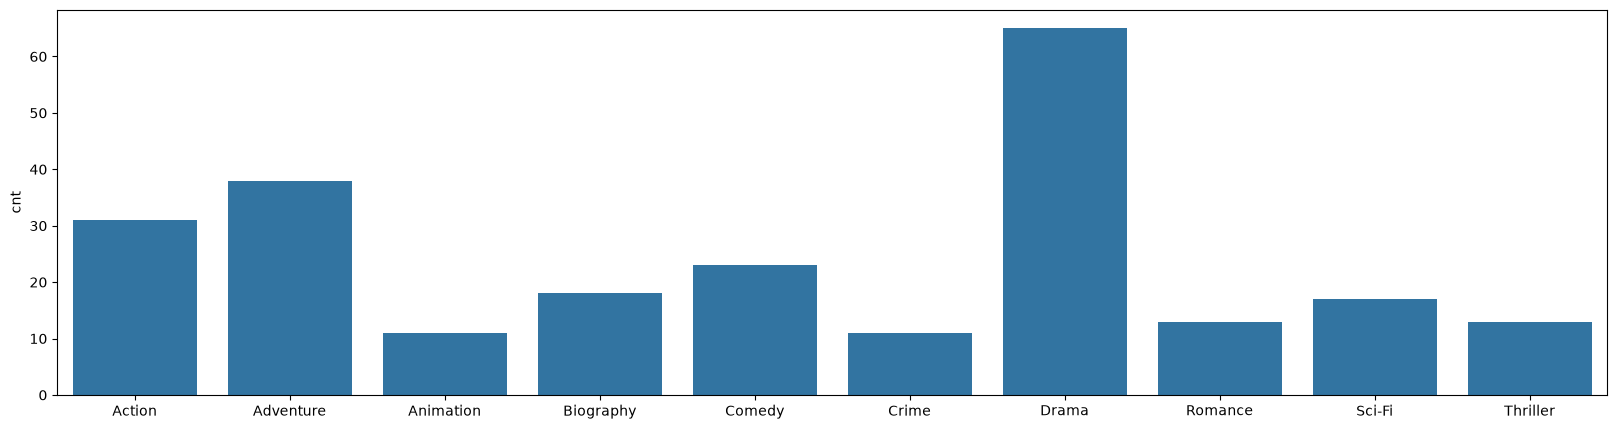

In [182]:
plt.figure(figsize=(20, 5))
sns.barplot(x=genre_top10.index.values, y=genre_top10['cnt'],data=genre_top10)

**`Checkpoint 5:`** Is the bar for `Drama` the tallest? Yes

-  ###  Subtask 3.3: Gender and Genre

If you have closely looked at the Votes- and CVotes-related columns, you might have noticed the suffixes `F` and `M` indicating Female and Male. Since we have the vote counts for both males and females, across various age groups, let's now see how the popularity of genres vary between the two genders in the dataframe. 

1. Make the first heatmap to see how the average number of votes of males is varying across the genres. Use seaborn heatmap for this analysis. The X-axis should contain the four age-groups for males, i.e., `CVotesU18M`,`CVotes1829M`, `CVotes3044M`, and `CVotes45AM`. The Y-axis will have the genres and the annotation in the heatmap tell the average number of votes for that age-male group. 

2. Make the second heatmap to see how the average number of votes of females is varying across the genres. Use seaborn heatmap for this analysis. The X-axis should contain the four age-groups for females, i.e., `CVotesU18F`,`CVotes1829F`, `CVotes3044F`, and `CVotes45AF`. The Y-axis will have the genres and the annotation in the heatmap tell the average number of votes for that age-female group. 

3. Make sure that you plot these heatmaps side by side using `subplots` so that you can easily compare the two genders and derive insights.

4. Write your any three inferences from this plot. You can make use of the previous bar plot also here for better insights.
Refer to this link- https://seaborn.pydata.org/generated/seaborn.heatmap.html. You might have to plot something similar to the fifth chart in this page (You have to plot two such heatmaps side by side).

5. Repeat subtasks 1 to 4, but now instead of taking the CVotes-related columns, you need to do the same process for the Votes-related columns. These heatmaps will show you how the two genders have rated movies across various genres.

You might need the below link for formatting your heatmap.
https://stackoverflow.com/questions/56942670/matplotlib-seaborn-first-and-last-row-cut-in-half-of-heatmap-plot

-  Note : Use `genre_top10` dataframe for this subtask

Text(0.5, 1.0, 'Cvotes by females')

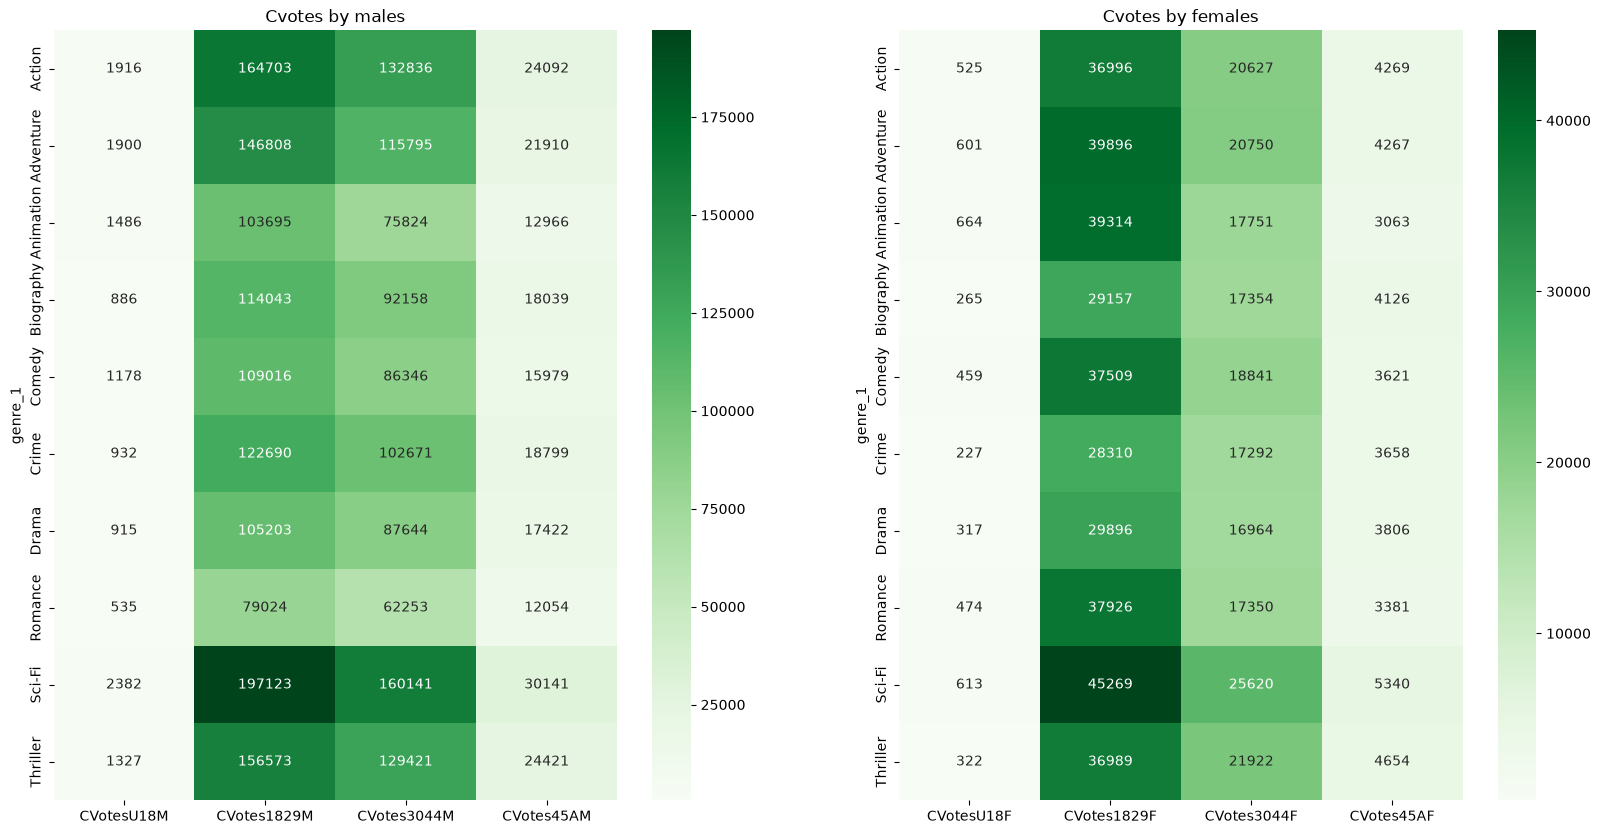

In [198]:
# 1st set of heat maps for CVotes-related columns
plt.figure(figsize=(20, 10))

plt.subplot(1, 2, 1)
sns.heatmap(genre_top10[['CVotesU18M','CVotes1829M', 'CVotes3044M', 'CVotes45AM']], annot=True, cmap='Greens',fmt='d')
plt.title('Cvotes by males')


plt.subplot(1, 2, 2)
sns.heatmap(genre_top10[['CVotesU18F','CVotes1829F', 'CVotes3044F', 'CVotes45AF']], annot=True, cmap='Greens',fmt='d')
plt.title('Cvotes by females')



**`Inferences:`** A few inferences that can be seen from the heatmap above is that males have voted more than females, and Sci-Fi appears to be most popular among the 18-29 age group irrespective of their gender. What more can you infer from the two heatmaps that you have plotted? Write your three inferences/observations below:
- Inference 1:Males show stronger vote counts across most genres, especially in younger age groups, so the male 18-29 and 30-44 segments are the dominant contributors to CVotes overall.
- Inference 2:For females, the highest vote volumes are concentrated in a smaller set of genres; genres like Romance and Drama likely stand out more for female voters than for male voters.
- Inference 3:Older age groups (30-44 and 45+) have much lower CVotes in most genres, which suggests the peak viewer engagement in this dataset is from younger voters, and genre popularity narrows as age increases.

In [42]:
# 2nd set of heat maps for Votes-related columns



**`Inferences:`** Sci-Fi appears to be the highest rated genre in the age group of U18 for both males and females. Also, females in this age group have rated it a bit higher than the males in the same age group. What more can you infer from the two heatmaps that you have plotted? Write your three inferences/observations below:
- Inference 1:
- Inference 2:
- Inference 3:

-  ###  Subtask 3.4: US vs non-US Cross Analysis

The dataset contains both the US and non-US movies. Let's analyse how both the US and the non-US voters have responded to the US and the non-US movies.

1. Create a column `IFUS` in the dataframe `movies`. The column `IFUS` should contain the value "USA" if the `Country` of the movie is "USA". For all other countries other than the USA, `IFUS` should contain the value `non-USA`.


2. Now make a boxplot that shows how the number of votes from the US people i.e. `CVotesUS` is varying for the US and non-US movies. Make use of the column `IFUS` to make this plot. Similarly, make another subplot that shows how non US voters have voted for the US and non-US movies by plotting `CVotesnUS` for both the US and non-US movies. Write any of your two inferences/observations from these plots.


3. Again do a similar analysis but with the ratings. Make a boxplot that shows how the ratings from the US people i.e. `VotesUS` is varying for the US and non-US movies. Similarly, make another subplot that shows how `VotesnUS` is varying for the US and non-US movies. Write any of your two inferences/observations from these plots.

Note : Use `movies` dataframe for this subtask. Make use of this documention to format your boxplot - https://seaborn.pydata.org/generated/seaborn.boxplot.html

In [204]:
# Creating IFUS column

data['IFUS']=data['Country'].apply(lambda x: 'USA' if x=='USA' else 'Non-USA')
data.head()

,Title,title_year,budget,Gross,actor_1_name,actor_2_name,actor_3_name,actor_1_facebook_likes,actor_2_facebook_likes,actor_3_facebook_likes,...,Votes3044F,Votes45A,Votes45AM,Votes45AF,Votes1000,VotesUS,VotesnUS,content_rating,Country,IFUS
0,La La Land,2016,30000000,151101803,Ryan Gosling,Emma Stone,Amiée Conn,14000,19000.0,NaN,...,7.8,7.6,7.6,7.5,7.1,8.3,8.1,PG-13,USA,USA
1,Zootopia,2016,150000000,341268248,Ginnifer Goodwin,Jason Bateman,Idris Elba,2800,28000.0,27000.0,...,8.1,7.8,7.8,8.1,7.6,8.0,8.0,PG,USA,USA
2,Lion,2016,12000000,51738905,Dev Patel,Nicole Kidman,Rooney Mara,33000,96000.0,9800.0,...,8.2,8.0,7.9,8.4,7.1,8.1,8.0,PG-13,Australia,Non-USA
3,Arrival,2016,47000000,100546139,Amy Adams,Jeremy Renner,Forest Whitaker,35000,5300.0,NaN,...,7.8,7.6,7.6,7.7,7.3,8.0,7.9,PG-13,USA,USA
4,Manchester by the Sea,2016,9000000,47695371,Casey Affleck,Michelle Williams,Kyle Chandler,518,71000.0,3300.0,...,7.7,7.6,7.6,7.6,7.1,7.9,7.8,R,USA,USA


<Axes: xlabel='CVotesnUS', ylabel='IFUS'>

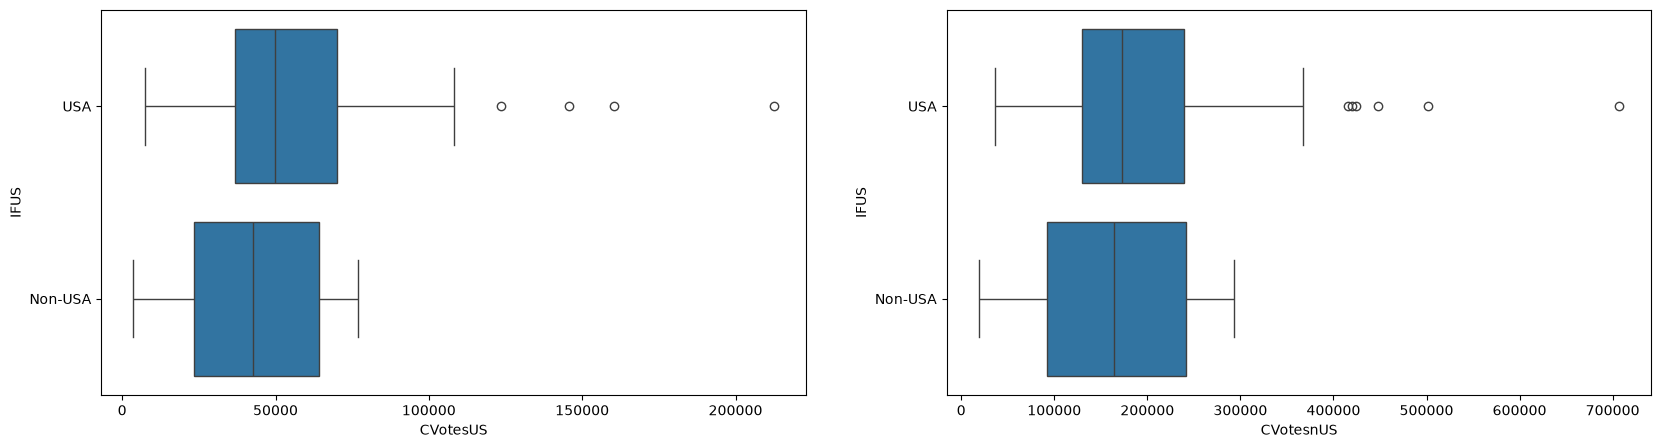

In [206]:
# Box plot - 1: CVotesUS(y) vs IFUS(x)

plt.figure(figsize=(20, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=data,y='IFUS',x='CVotesUS')

plt.subplot(1, 2, 2)
sns.boxplot(data=data,y='IFUS',x='CVotesnUS')

**`Inferences:`** Write your two inferences/observations below:
- Inference 1:US voters give significantly more cumulative votes to US movies than to non-US movies, so the median CVotesUS is higher for IFUS = USA.
- Inference 2:Non-US movies show a lower and tighter CVotesUS distribution on the box plot, indicating US vote activity is weaker and less variable for non-US films.

<Axes: xlabel='VotesnUS', ylabel='IFUS'>

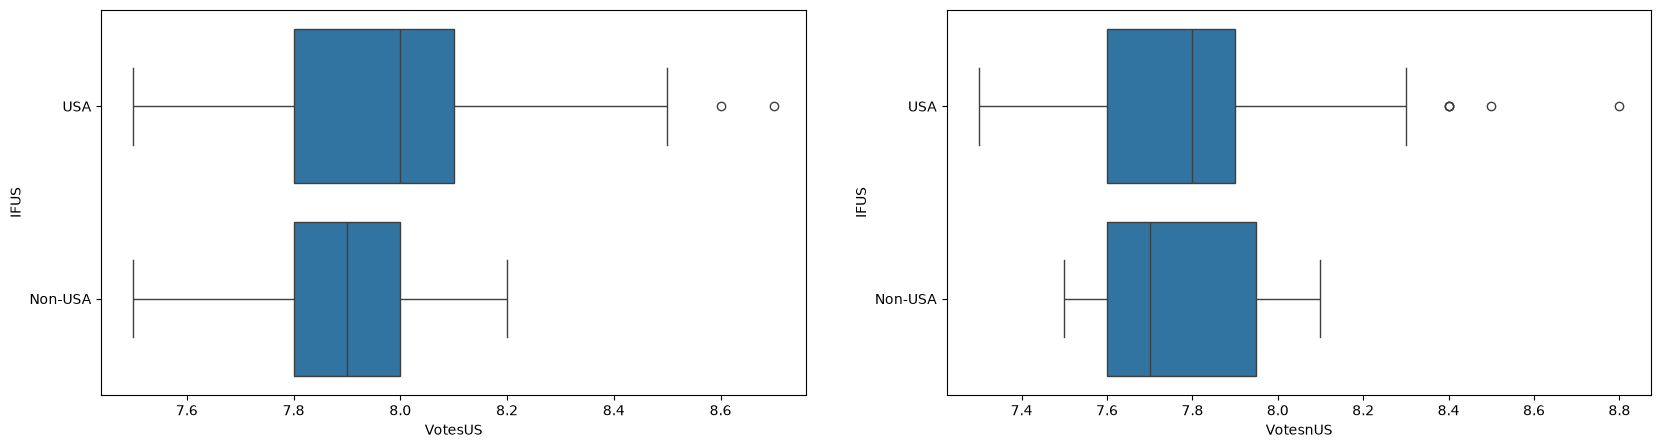

In [207]:
# Box plot - 2: VotesUS(y) vs IFUS(x)
plt.figure(figsize=(20, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=data,y='IFUS',x='VotesUS')

plt.subplot(1, 2, 2)
sns.boxplot(data=data,y='IFUS',x='VotesnUS')


**`Inferences:`** Write your two inferences/observations below:
- Inference 1:US movies tend to receive higher median VotesUS scores than non-US movies, suggesting US viewers rate domestic films more favorably.
- Inference 2:Non-US movies show a narrower and lower VotesUS distribution, meaning US voters are both less varied and typically less generous with ratings for non-US films.

-  ###  Subtask 3.5:  Top 1000 Voters Vs Genres

You might have also observed the column `CVotes1000`. This column represents the top 1000 voters on IMDb and gives the count for the number of these voters who have voted for a particular movie. Let's see how these top 1000 voters have voted across the genres. 

1. Sort the dataframe genre_top10 based on the value of `CVotes1000`in a descending order.

2. Make a seaborn barplot for `genre` vs `CVotes1000`.

3. Write your inferences. You can also try to relate it with the heatmaps you did in the previous subtasks.




In [214]:
# Sorting by CVotes1000
genre_top10_sorted = genre_top10.sort_values(by='CVotes1000', ascending=False)

genre_top10_sorted.head()


,CVotes10,CVotes09,CVotes08,CVotes07,CVotes06,CVotes05,CVotes04,CVotes03,CVotes02,CVotes01,...,Votes3044M,Votes3044F,Votes45A,Votes45AM,Votes45AF,Votes1000,VotesUS,VotesnUS,cnt,IFUS
genre_1,,,,,,,,,,,,,,,,,,,,,
Sci-Fi,136781,148873,176646,106005,39518,14951,6583,3876,2715,6731,...,7.85,7.84,7.71,7.69,7.74,7.52,8.09,7.88,17.0,NaN
Action,102144,114433,150895,94262,34688,12693,5386,3064,2115,5524,...,7.73,7.80,7.65,7.63,7.75,7.30,7.99,7.76,31.0,NaN
Thriller,83207,112730,153336,90446,32003,11534,5021,2918,1982,4433,...,7.75,7.70,7.66,7.64,7.75,7.40,7.93,7.81,13.0,NaN
Adventure,94596,105636,138482,86367,31896,11551,4817,2718,1835,4575,...,7.73,7.87,7.68,7.64,7.84,7.38,7.99,7.79,38.0,NaN
Crime,52229,87919,129045,74671,25308,8971,3842,2246,1544,3383,...,7.76,7.61,7.63,7.62,7.68,7.39,7.98,7.80,11.0,NaN


<Axes: ylabel='CVotes1000'>

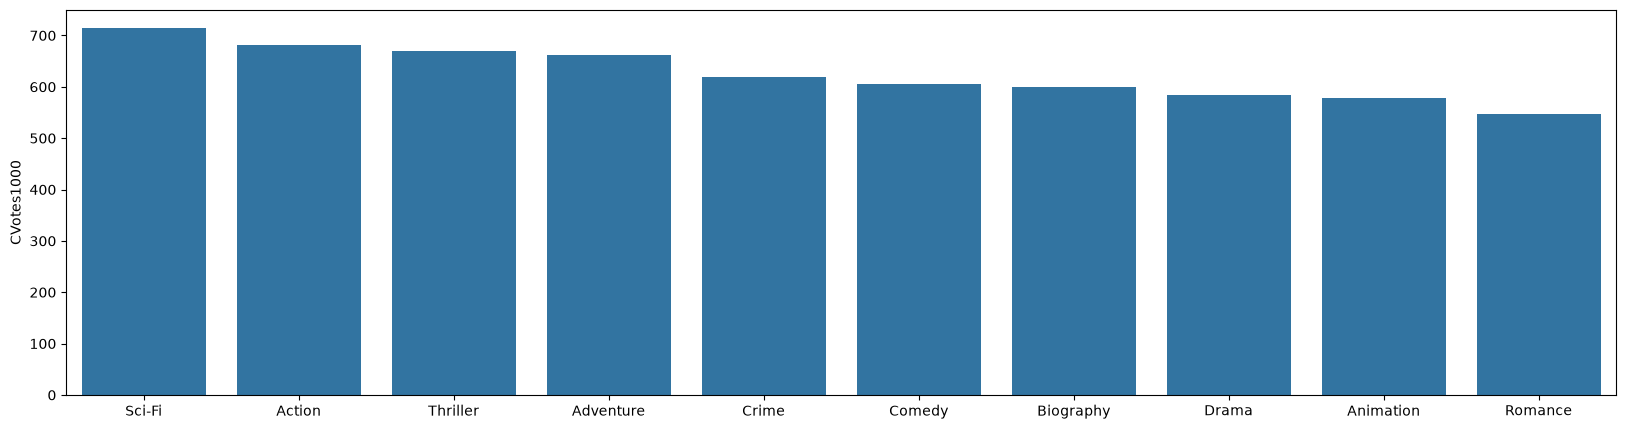

In [216]:
# Bar plot
plt.figure(figsize=(20, 5))
sns.barplot(x=genre_top10_sorted.index.values, y=genre_top10_sorted['CVotes1000'],data=genre_top10_sorted)

**`Inferences:`** Write your inferences/observations here.
Romance is among the lowest in CVotes1000, indicating top-1000 voters engage less with Romance.

**`Checkpoint 6:`** The genre `Romance` seems to be most unpopular among the top 1000 voters.
Yes, Romance is most unpopular among the top 1000 voters.

With the above subtask, your assignment is over. In your free time, do explore the dataset further on your own and see what kind of other insights you can get across various other columns.